<a href="https://colab.research.google.com/github/JanuNandhini/24AD004_DSV_TEAM_13/blob/main/final_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week 3:

The required Python libraries are imported for data manipulation, numerical operations, visualization, and statistical analysis. The crime dataset is then loaded using Pandas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("/content/Crime_Data_from_2020_to_Present.csv")





Displays the count of missing values in each column of the dataset.

Helps understand data quality and identify incomplete fields.

Renames important columns for better readability and easier usage:


Crm Cd Desc → Crime Description

TIME OCC → Time

DATE OCC → Date

LAT → Latitude

LON → Longitude

Removes rows where Latitude and Longitude are missing, since location is essential for spatial analysis and crime hotspot mapping.

In [2]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df.rename(columns={
    'Crm Cd Desc': 'Crime Description',
    'TIME OCC': 'Time',
    'DATE OCC': 'Date',
    'LAT': 'Latitude',
    'LON': 'Longitude'
}, inplace=True)

df.dropna(subset=['Latitude', 'Longitude'], inplace=True)

Missing values before cleaning:
DR_NO                 0
Date Rptd             0
DATE OCC              0
TIME OCC              0
AREA                  0
AREA NAME             0
Rpt Dist No           0
Part 1-2              0
Crm Cd                0
Crm Cd Desc           0
Mocodes            2703
Vict Age              0
Vict Sex           2613
Vict Descent       2616
Premis Cd             1
Premis Desc          13
Weapon Used Cd    12650
Weapon Desc       12650
Status                1
Status Desc           1
Crm Cd 1              2
Crm Cd 2          18693
Crm Cd 3          20303
Crm Cd 4          20343
LOCATION              1
Cross Street      16506
LAT                   1
LON                   1
dtype: int64


Missing crime descriptions are replaced with "Unknown"

Missing time values are replaced using mode (most frequent value)

Date column is converted into proper datetime format

Hour is extracted from time (24-hour format)


Invalid hour values are removed

In [3]:
df['Crime Description'] = df['Crime Description'].fillna('Unknown')

df['Time'] = df['Time'].fillna(df['Time'].mode()[0])

df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')


df['Time'] = df['Time'].astype(str).str.zfill(4)
df['Hour'] = df['Time'].str[:2].astype(int)

df = df[(df['Hour'] >= 0) & (df['Hour'] <= 23)]

A new feature called Time of Day is created to categorize crimes into Morning, Afternoon, Evening, and Night. Crime descriptions are also standardized by converting text to lowercase and removing extra spaces

In [4]:

def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_of_Day'] = df['Hour'].apply(time_of_day)


df['Crime Description'] = df['Crime Description'].str.lower().str.strip()

In [5]:
crime_per_hour = df.groupby('Hour').size()

z_scores = np.abs(stats.zscore(crime_per_hour))
crime_per_hour_cleaned = crime_per_hour[z_scores < 3]

A box plot is used to visualize the distribution of crime frequency across different hours and detect outliers in the data.

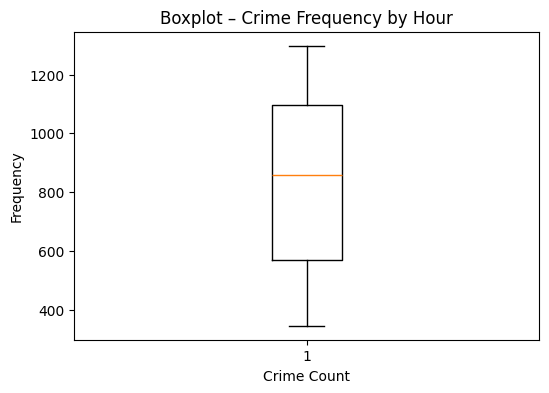

In [6]:
plt.figure(figsize=(6,4))
plt.boxplot(crime_per_hour.values)
plt.title("Boxplot – Crime Frequency by Hour")
plt.xlabel("Crime Count")
plt.ylabel("Frequency")
plt.show()

A bar chart is used to show how crime occurrences vary across different hours of the day, helping identify peak crime timings.

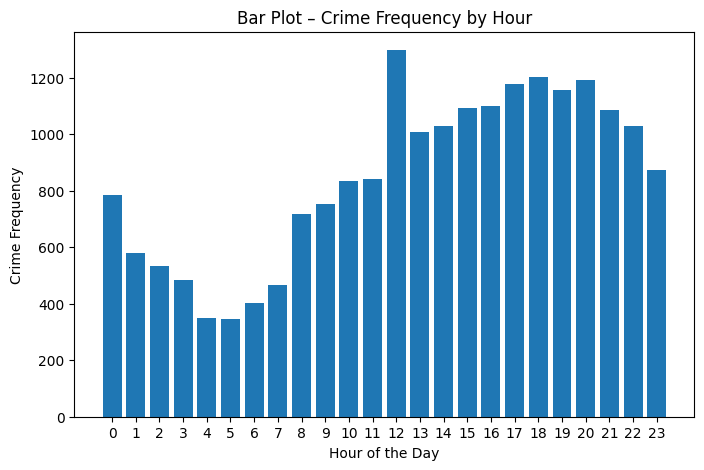

In [7]:
plt.figure(figsize=(8,5))
plt.bar(crime_per_hour.index, crime_per_hour.values)
plt.title("Bar Plot – Crime Frequency by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Crime Frequency")
plt.xticks(range(0,24))
plt.show()


In [8]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nCleaned dataset preview:")
print(df[['Date','Hour','Time_of_Day','Latitude','Longitude','Crime Description']].head())

df.to_csv("cleaned_crime_data.csv", index=False)


Missing values after cleaning:
DR_NO                    0
Date Rptd                0
Date                 20344
Time                     0
AREA                     0
AREA NAME                0
Rpt Dist No              0
Part 1-2                 0
Crm Cd                   0
Crime Description        0
Mocodes               2703
Vict Age                 0
Vict Sex              2613
Vict Descent          2615
Premis Cd                0
Premis Desc             12
Weapon Used Cd       12649
Weapon Desc          12649
Status                   0
Status Desc              0
Crm Cd 1                 1
Crm Cd 2             18692
Crm Cd 3             20302
Crm Cd 4             20342
LOCATION                 0
Cross Street         16505
Latitude                 0
Longitude                0
Hour                     0
Time_of_Day              0
dtype: int64

Cleaned dataset preview:
  Date  Hour Time_of_Day  Latitude  Longitude  \
0  NaT    21       Night   34.0375  -118.3506   
1  NaT    18     Even